# Лабораторна робота № 1
## Тема: Підсумкові функції та відображення
**Дисципліна**: Основи науки про дані  
**Кафедра**: Обчислювальної техніки, ФІОТ, НТУУ «КПІ ім. Ігоря Сікорського»  
**Викладач**: д.т.н., проф. Новотарський М. А.  

---

### Мета роботи:
Навчитися вибирати відповідні дані з об'єктів `DataFrame` та `Series`, застосовувати прості підсумкові (зведені) функції (`describe()`, `mean()`, `unique()`, `value_counts()`), виконувати перетворення даних за допомогою відображень (`map()`, `apply()`), а також практично оцінити переваги вбудованих векторизованих операцій бібліотеки Pandas.

### Інформація про набір даних:
* **Назва**: Video Game Sales (продажі відеоігор, наклад яких перевищив 100 000 копій)
* **Джерело**: [Kaggle - Video Game Sales Dataset](https://www.kaggle.com/datasets/gregorut/videogamesales)
* **Обсяг**: 16 539 записів, 10 ознак (назва, платформа, рік релізу, жанр, видавець, продажі за регіонами NA, EU, JP, Other та загальні світові продажі Global_Sales).

### 1. Ініціалізація робочого середовища та імпорт бібліотек
Підключаємо бібліотеки для аналізу даних (`pandas`, `numpy`) та побудови графіків (`matplotlib.pyplot`, `seaborn`). Налаштовуємо акуратний стиль відображення та параметри таблиць.

In [1]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування візуалізації та стилю
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

# Налаштування відображення таблиць у Pandas
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 2)

print("Бібліотеки успішно імпортовано. Pandas версії:", pd.__version__)

Бібліотеки успішно імпортовано. Pandas версії: 3.0.6


### 2. Завантаження та первинний огляд набору даних
Зчитуємо набір даних `vgsales.csv` з підпапки `data/` та виводимо перші 10 рядків датафрейму для ознайомлення зі структурою та типами ознак.

In [2]:
# Завантаження датасету
games_df = pd.read_csv('data/vgsales.csv')

# Перегляд перших 10 записів
games_df.head(10)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Kaboom!,2600,1980.0,Misc,Activision,1.07,0.07,0.0,0.01,1.15
1,Boxing,2600,1980.0,Fighting,Activision,0.72,0.04,0.0,0.01,0.77
2,Ice Hockey,2600,1980.0,Sports,Activision,0.46,0.03,0.0,0.01,0.49
3,Freeway,2600,1980.0,Action,Activision,0.32,0.02,0.0,0.00,0.34
4,Bridge,2600,1980.0,Misc,Activision,0.25,0.02,0.0,0.00,0.27
5,Asteroids,2600,1980.0,Shooter,Atari,4.00,0.26,0.0,0.05,4.31
6,Missile Command,2600,1980.0,Shooter,Atari,2.56,0.17,0.0,0.03,2.76
7,Defender,2600,1980.0,Misc,Atari,0.99,0.05,0.0,0.01,1.05
8,Checkers,2600,1980.0,Misc,Atari,0.22,0.01,0.0,0.00,0.24
9,Alien,2600,1981.0,Action,20th Century Fox Video Games,0.74,0.04,0.0,0.01,0.79


Перевіряємо розмірність датасету (`shape`), типи стовпців та наявність ненульових значень за допомогою методу `.info()`.

In [3]:
print(f"Розмірність датасету: {games_df.shape[0]} рядків, {games_df.shape[1]} стовпців\n")
games_df.info()

Розмірність датасету: 16539 рядків, 10 стовпців

<class 'pandas.DataFrame'>
RangeIndex: 16539 entries, 0 to 16538
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16539 non-null  str    
 1   Platform      16539 non-null  str    
 2   Year          16290 non-null  float64
 3   Genre         16539 non-null  str    
 4   Publisher     16539 non-null  str    
 5   NA_Sales      16539 non-null  float64
 6   EU_Sales      16539 non-null  float64
 7   JP_Sales      16539 non-null  float64
 8   Other_Sales   16539 non-null  float64
 9   Global_Sales  16539 non-null  float64
dtypes: float64(6), str(4)
memory usage: 1.3 MB


---
### 3. Застосування підсумкових функцій (Summary Functions)

Підсумкові функції бібліотеки Pandas дозволяють агрегувати та структурувати інформацію, отримуючи компактний числовий або категоріальний огляд розподілу даних.

Розглянемо ключові підсумкові функції, визначені методичними вказівками:
* `describe()` — генерує комплексний статистичний підсумок для числових або категоріальних даних.
* `unique()` — повертає масив усіх унікальних значень стовпця.
* `mean()` — розраховує середнє арифметичне значення числового стовпця.
* `value_counts()` — обчислює частоту появи кожного унікального значення в стовпці.

#### 3.1. Метод `describe()` для числового стовпця
Застосовуємо метод `describe()` до числового стовпця `Global_Sales` (загальний обсяг продажів відеогри по всьому світу в мільйонах копій).

Метод повертає ключові статистичні характеристики:
- **count**: кількість непорожніх значень;
- **mean**: середнє арифметичне значення;
- **std**: стандартне (середньоквадратичне) відхилення;
- **min**: мінімальне зафіксоване значення;
- **25%**: перший квартиль (25% ігор мають продажі, не вищі за це значення);
- **50%**: медіана (другий квартиль — центральне значення розподілу);
- **75%**: третій квартиль (75% ігор мають продажі, не вищі за це значення);
- **max**: максимальний обсяг продажів (абсолютний рекордсмен серед ігор).

In [4]:
# Підсумкова статистика по стовпцю Global_Sales
games_df.Global_Sales.describe()

count    16539.00
mean         0.54
std          1.56
min          0.01
25%          0.06
50%          0.17
75%          0.48
max         82.74
Name: Global_Sales, dtype: float64

#### 3.2. Метод `unique()` для числових даних
Метод `unique()` виводить масив усіх унікальних числових значень стовпця `Global_Sales`.

In [5]:
# Унікальні значення продажів (перші 20 значень)
sales_unique = games_df.Global_Sales.unique()
print(f"Загальна кількість унікальних значень продажів: {len(sales_unique)}")
print("Приклади унікальних значень:", sales_unique[:20])

Загальна кількість унікальних значень продажів: 623
Приклади унікальних значень: [1.15 0.77 0.49 0.34 0.27 4.31 2.76 1.05 0.24 0.79 0.22 4.5  1.6  1.1
 0.48 0.43 0.39 1.97 1.65 1.36]


#### 3.3. Метод `mean()` для числового стовпця
Розраховуємо середнє арифметичне значення світових продажів відеоігор за допомогою методу `.mean()`. Цей метод застосовний лише до числових ознак.

In [6]:
# Розрахунок середнього значення по стовпцю Global_Sales
global_sales_mean = games_df.Global_Sales.mean()
print(f"Середній обсяг продажів однієї гри у світі: {global_sales_mean:.4f} млн копій")

Середній обсяг продажів однієї гри у світі: 0.5384 млн копій


#### 3.4. Метод `unique()` для категоріального стовпця
Визначаємо список унікальних категорій у стовпці `Genre` (ігрові жанри) та `Platform` (ігрові платформи).

In [7]:
# Унікальні жанри відеоігор
genres = games_df.Genre.unique()
print(f"Кількість унікальних жанрів ({len(genres)}):\n", genres)

print("\n" + "="*60 + "\n")

# Унікальні платформи
platforms = games_df.Platform.unique()
print(f"Кількість унікальних платформ ({len(platforms)}):\n", platforms)

Кількість унікальних жанрів (12):
 <StringArray>
['Misc', 'Fighting', 'Sports', 'Action', 'Shooter', 'Platform', 'Racing', 'Puzzle', 'Simulation', 'Adventure', 'Role-Playing', 'Strategy']
Length: 12, dtype: str


Кількість унікальних платформ (31):
 <StringArray>
['2600', 'NES', 'PC', 'DS', 'GB', 'SNES', 'GEN', 'GG', 'SCD', 'NG', 'SAT', 'PS', '3DO', 'TG16', 'N64', 'PCFX', 'DC', 'WS', 'PS2', 'GBA', 'XB', 'GC', 'PSP', 'X360', 'PS3', 'Wii', '3DS', 'PSV', 'WiiU', 'PS4', 'XOne']
Length: 31, dtype: str


#### 3.5. Метод `describe()` для категоріального (текстового) стовпця
Згідно з методичними вказівками, поведінка методу `describe()` істотно змінюється залежно від типу вхідного стовпця. Для категоріальних даних (`object`) метод виводить такі параметри:
- **count**: загальна кількість непорожніх записів;
- **unique**: кількість унікальних категорій у стовпці;
- **top**: найчастіша категорія (мода розподілу);
- **freq**: частота появи найпопулярнішої категорії.

In [8]:
# Огляд категоріального стовпця 'Genre'
games_df.Genre.describe()

count      16539
unique        12
top       Action
freq        3309
Name: Genre, dtype: object

#### 3.6. Метод `value_counts()`
Метод `value_counts()` підраховує, скільки разів кожне унікальне значення трапляється у наборі даних, та автоматично сортує результати за спаданням частоти.

In [9]:
# Частотний розподіл ігор за жанрами
genre_counts = games_df.Genre.value_counts()
genre_counts

Genre
Action          3309
Sports          2343
Misc            1712
Role-Playing    1486
Shooter         1308
Adventure       1282
Racing          1248
Platform         884
Simulation       862
Fighting         846
Strategy         678
Puzzle           581
Name: count, dtype: int64

In [10]:
# Топ-10 ігрових платформ за кількістю випущених ігор
platform_counts = games_df.Platform.value_counts()
platform_counts.head(10)

Platform
PS2     2159
DS      2155
PS3     1326
Wii     1324
X360    1261
PSP     1211
PS      1193
PC       954
XB       824
GBA      796
Name: count, dtype: int64

---
### 4. Застосування відображень (Mappings)

**Відображення** — це математична концепція перетворення набору значень з однієї множини в іншу відповідно до заданого функціонального правила $f: X \to Y$.
У задачах науки про дані відображення дозволяють трансформувати вихідні ознаки у зручніший аналітичний формат.

Бібліотека Pandas надає два фундаментальні методи відображень:
1. **`map()`**: застосовує задану функцію (або словник) поелементно до об'єкта `Series` та повертає новий перетворений `Series`.
2. **`apply()`**: застосовує користувацьку функцію до кожного рядка (за умови `axis='columns'` або `axis=1`) чи кожного стовпця (`axis='index'` або `axis=0`) об'єкта `DataFrame`. Повертає трансформований новий `DataFrame`.

> **Важлива властивість**: Методи `map()` та `apply()` є чистими функціями — вони не змінюють вихідний датафрейм *in-place*, а повертають новий об'єкт.

#### 4.1. Використання методу `map()`
Центруємо шкалу продажів відеоігор за допомогою методу `map()`. Від кожного значення `Global_Sales` віднімемо розраховане раніше середнє значення `global_sales_mean`.

*Інтерпретація отриманих даних*:  
* Значення `0.0` тепер відповідає середньостатистичній грі на ринку;
* Додатні значення показують, на скільки мільйонів копій успішна гра перевищила середній ринковий показник;
* Від'ємні значення відповідають іграм з продажами нижче середнього рівня.

In [11]:
# Застосування map() для центрування продажів
sales_centered_map = games_df.Global_Sales.map(lambda s: s - global_sales_mean)

# Виведення перших 10 центрованих значень
sales_centered_map.head(10)

0    0.61
1    0.23
2   -0.05
3   -0.20
4   -0.27
5    3.77
6    2.22
7    0.51
8   -0.30
9    0.25
Name: Global_Sales, dtype: float64

#### 4.2. Використання методу `apply()` з `axis='columns'`
Реалізуємо власну функцію для комплексної построкової трансформації датафрейму. У кожному рядку ми:
1. Центруємо показник світових продажів `Global_Sales` відносно середнього значення;
2. Обчислюємо нову колонку `Estimated_Gross_Revenue_M$` (орієнтовний валовий виторг у млн доларів США), виходячи із середньої роздрібної ціни $50 за одну фізичну копію гри ($Revenue = Sales \times 50$).

In [12]:
def transform_game_data(row):
    """
    Користувацька функція для обробки рядка датафрейму:
    - центрує показник світових продажів;
    - розраховує орієнтовну валову виручку у мільйонах доларів США.
    """
    # Розраховуємо орієнтовний виторг (до центрування самого значення)
    row['Estimated_Gross_Revenue_M$'] = row['Global_Sales'] * 50.0
    # Центруємо продажі відносно середнього
    row['Global_Sales'] = row['Global_Sales'] - global_sales_mean
    return row

# Застосовуємо функцію до кожного рядка DataFrame (axis='columns')
transformed_games_df = games_df.apply(transform_game_data, axis='columns')

# Виводимо перші 5 рядків трансформованого датафрейму
transformed_games_df[['Name', 'Platform', 'Genre', 'Global_Sales', 'Estimated_Gross_Revenue_M$']].head(5)

,Name,Platform,Genre,Global_Sales,Estimated_Gross_Revenue_M$
0,Kaboom!,2600,Misc,0.61,57.5
1,Boxing,2600,Fighting,0.23,38.5
2,Ice Hockey,2600,Sports,-0.05,24.5
3,Freeway,2600,Action,-0.20,17.0
4,Bridge,2600,Misc,-0.27,13.5


#### 4.3. Перевірка незмінності початкових даних
Переконуємося, що вихідний об'єкт `games_df` залишився абсолютно незмінним після виконання методів `map()` та `apply()`.

In [13]:
# Перевірка перших 5 рядків вихідного датафрейму
games_df[['Name', 'Platform', 'Genre', 'Global_Sales']].head(5)

,Name,Platform,Genre,Global_Sales
0,Kaboom!,2600,Misc,1.15
1,Boxing,2600,Fighting,0.77
2,Ice Hockey,2600,Sports,0.49
3,Freeway,2600,Action,0.34
4,Bridge,2600,Misc,0.27


---
### 5. Вбудовані векторизовані операції над стовпцями

Бібліотека Pandas надає оптимізовані вбудовані векторизовані операції, які виконують обчислення на рівні скомпільованого коду мови C (через ядро NumPy) над блоками пам'яті, минаючи повільні циклічні ітерації інтерпретатора Python.

Розглянемо два основні типи векторизованих операцій:
1. **Операція між стовпцем (`Series`) та скаляром (константою)**;
2. **Операція між двома стовпцями (`Series`) однакової довжини**.

#### 5.1. Операція між елементами стовпця та константою
Виконуємо ту ж саму дію центрування продажів, але замість виклику `.map(lambda ...)` застосовуємо прямий векторизований оператор віднімання скаляра `global_sales_mean` від стовпця `games_df.Global_Sales`.

In [14]:
# Векторизоване центрування значень
vectorized_centered_sales = games_df.Global_Sales - global_sales_mean
vectorized_centered_sales.head(10)

0    0.61
1    0.23
2   -0.05
3   -0.20
4   -0.27
5    3.77
6    2.22
7    0.51
8   -0.30
9    0.25
Name: Global_Sales, dtype: float64

#### 5.2. Порівняння продуктивності: векторизація проти `map()`
Проведемо точний бенчмарк часу виконання для 100 повторень обох підходів над масивом з 16 539 рядків.

In [15]:
iterations = 100

# Замір часу для map()
start_map = time.perf_counter()
for _ in range(iterations):
    _ = games_df.Global_Sales.map(lambda s: s - global_sales_mean)
duration_map = (time.perf_counter() - start_map) / iterations

# Замір часу для векторизованої операції Pandas
start_vec = time.perf_counter()
for _ in range(iterations):
    _ = games_df.Global_Sales - global_sales_mean
duration_vec = (time.perf_counter() - start_vec) / iterations

speedup = duration_map / duration_vec
print(f"Час виконання методу map():             {duration_map * 1000:.3f} мс")
print(f"Час вбудованої векторизованої операції: {duration_vec * 1000:.3f} мс")
print(f"Векторизована операція швидша у:        {speedup:.1f} разів!")

Час виконання методу map():             2.157 мс
Час вбудованої векторизованої операції: 0.027 мс
Векторизована операція швидша у:        80.8 разів!


#### 5.3. Операція між двома стовпцями однакової довжини
1. **Текстова конкатенація**: об'єднуємо два рядкових стовпці `Name` (назва) та `Platform` (платформа) у єдину репрезентативну мітку за допомогою оператора `+`.
2. **Числова арифметика**: обчислюємо сумарні продажі гри на західних ринках як пряму суму двох числових стовпців `NA_Sales` (Північна Америка) та `EU_Sales` (Європа).

In [16]:
# 1. Текстова конкатенація двох Series
game_with_platform = games_df.Name + " [" + games_df.Platform + "]"
print("Результат конкатенації текстових стовпців:")
print(game_with_platform.head(5))

print("\n" + "="*60 + "\n")

# 2. Арифметична дія між двома числовими стовпцями однакової довжини
western_sales = games_df.NA_Sales + games_df.EU_Sales
print("Сумарні продажі на Західному ринку (NA_Sales + EU_Sales, млн копій):")
print(western_sales.head(5))

Результат конкатенації текстових стовпців:
0       Kaboom! [2600]
1        Boxing [2600]
2    Ice Hockey [2600]
3       Freeway [2600]
4        Bridge [2600]
dtype: str


Сумарні продажі на Західному ринку (NA_Sales + EU_Sales, млн копій):
0    1.14
1    0.76
2    0.49
3    0.34
4    0.27
dtype: float64


---
### 6. Візуалізація результатів дослідження

Для наочного представлення отриманих результатів побудуємо графіки відповідно до вимог оформлення кафедри (обов'язкові заголовки, підписи осей, сітка та легенда) та збережемо їх у папку `figures/`.

Графік успішно збережено у: figures\genres_analysis.png


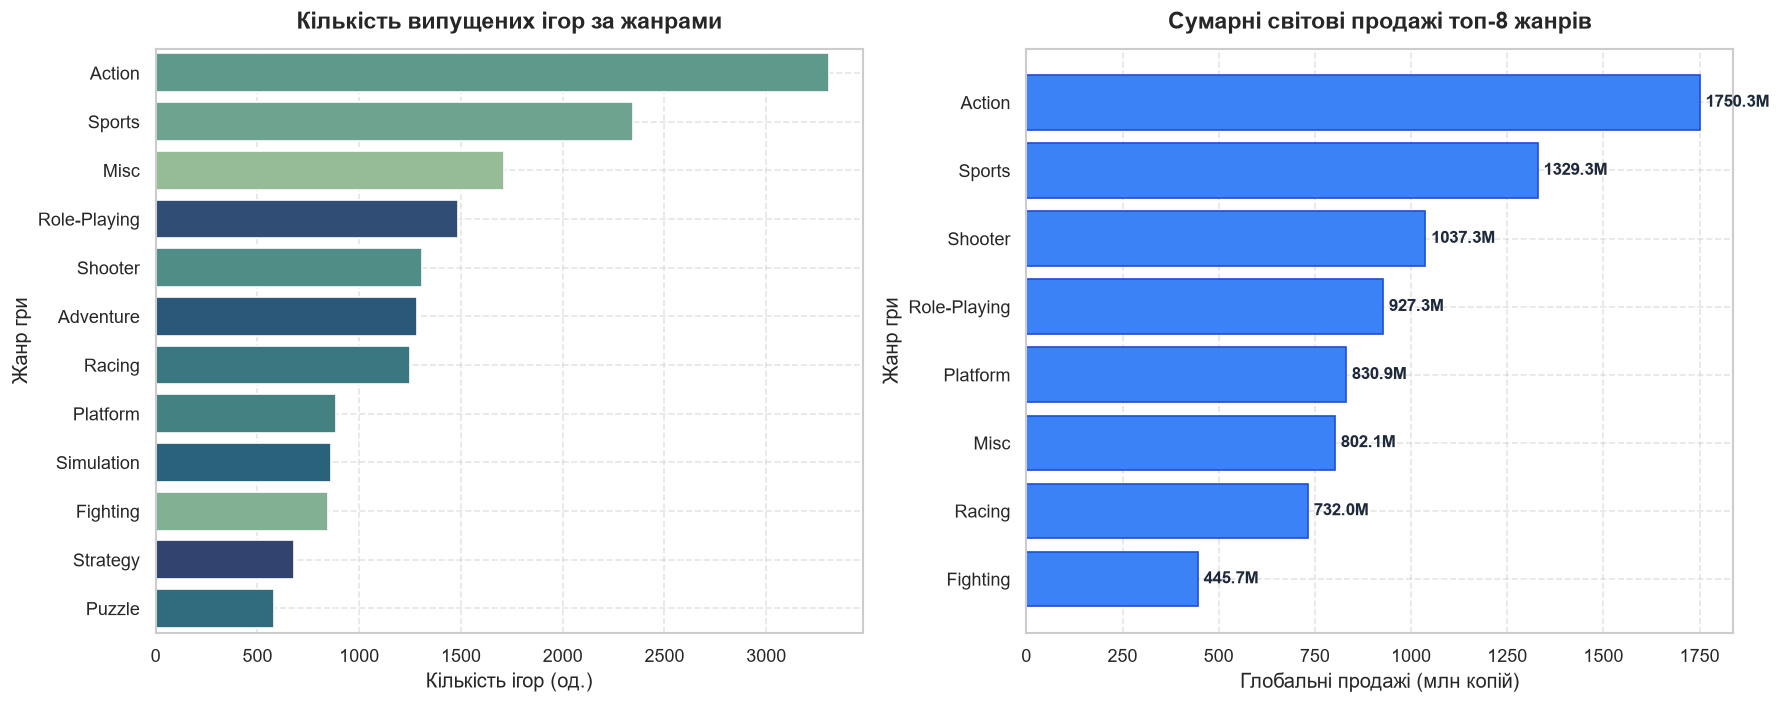

In [17]:
# Створюємо фігуру з двома підграфіками
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Графік 1: Розподіл релізів за ігровими жанрами
genre_order = games_df.Genre.value_counts().index
sns.countplot(
    data=games_df,
    y='Genre',
    order=genre_order,
    hue='Genre',
    legend=False,
    ax=axes[0],
    palette='crest'
)
axes[0].set_title('Кількість випущених ігор за жанрами', fontsize=14, pad=12, fontweight='bold')
axes[0].set_xlabel('Кількість ігор (од.)', fontsize=12)
axes[0].set_ylabel('Жанр гри', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Графік 2: Сумарні глобальні продажі за топ-8 жанрами
top_genres_sales = games_df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(8)
axes[1].barh(top_genres_sales.index, top_genres_sales.values, color='#3b82f6', edgecolor='#1d4ed8')
axes[1].invert_yaxis()  # Найбільший зверху
axes[1].set_title('Сумарні світові продажі топ-8 жанрів', fontsize=14, pad=12, fontweight='bold')
axes[1].set_xlabel('Глобальні продажі (млн копій)', fontsize=12)
axes[1].set_ylabel('Жанр гри', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Додавання підписів значень на стовпчики
for i, v in enumerate(top_genres_sales.values):
    axes[1].text(v + 15, i, f"{v:.1f}M", va='center', fontsize=10, fontweight='bold', color='#1e293b')

plt.tight_layout()

# Збереження графіків у файл
os.makedirs('figures', exist_ok=True)
fig_path = os.path.join('figures', 'genres_analysis.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Графік успішно збережено у: {fig_path}")
plt.show()

Графік топ-10 ігор збережено у: figures\top10_games.png


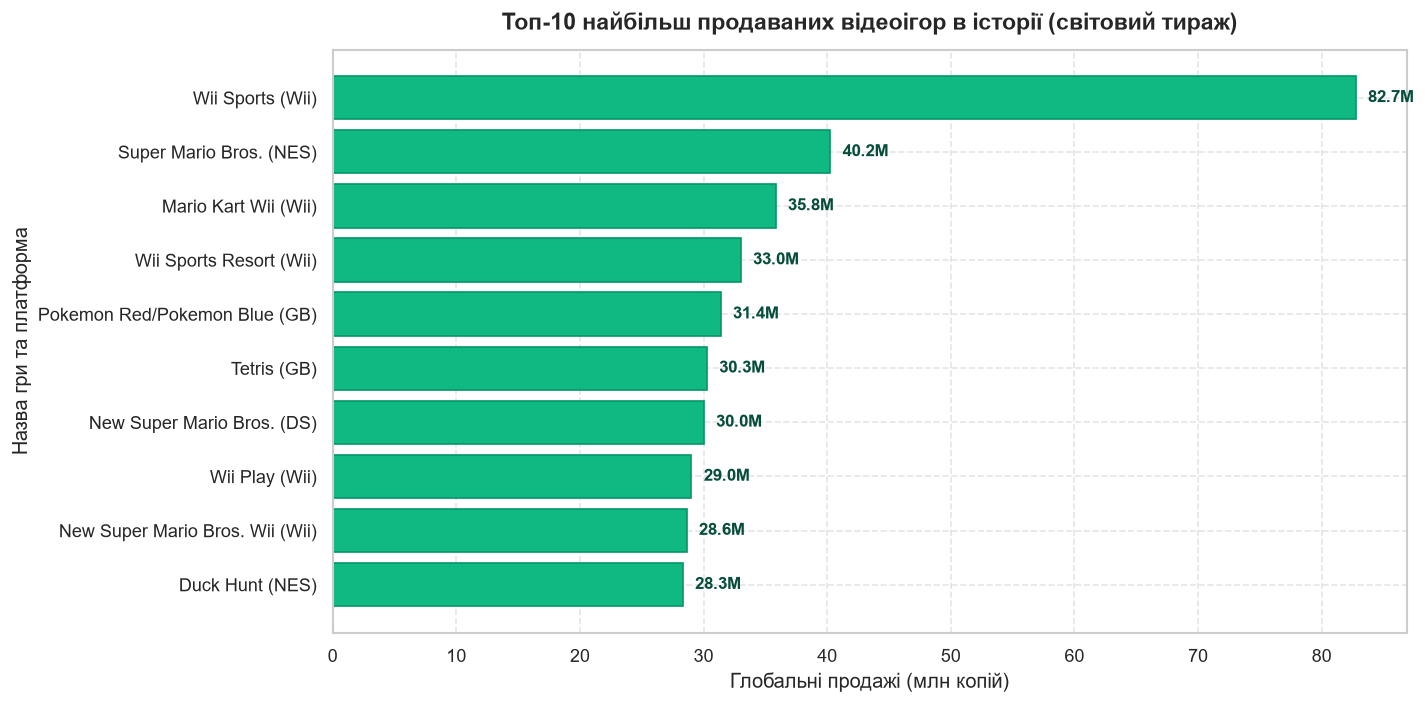

In [18]:
# Графік 3: Топ-10 найбільш продаваних відеоігор в історії
top10_games = games_df.sort_values(by='Global_Sales', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(
    top10_games['Name'] + " (" + top10_games['Platform'] + ")",
    top10_games['Global_Sales'],
    color='#10b981',
    edgecolor='#059669'
)
plt.gca().invert_yaxis()
plt.title('Топ-10 найбільш продаваних відеоігор в історії (світовий тираж)', fontsize=14, pad=12, fontweight='bold')
plt.xlabel('Глобальні продажі (млн копій)', fontsize=12)
plt.ylabel('Назва гри та платформа', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}M", va='center', fontsize=10, fontweight='bold', color='#064e3b')

plt.tight_layout()
fig2_path = os.path.join('figures', 'top10_games.png')
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f"Графік топ-10 ігор збережено у: {fig2_path}")
plt.show()

---
### 7. Висновки до лабораторної роботи

1. **Опанування підсумкових функцій**:
   - Метод `describe()` є універсальним інструментом первинного аналізу: для числових стовпців (`Global_Sales`) він обчислює міри центральної тенденції (середнє, медіана) та розсіювання (квартилі, дисперсія, розмах), а для категоріальних (`Genre`, `Platform`) — підсумовує кількість непорожніх записів, кількість унікальних категорій, моду розподілу (`top`) та її частоту (`freq`).
   - Методи `mean()`, `unique()` та `value_counts()` дають змогу швидко отримати агреговані показники та виявити ключові закономірності (зокрема, що жанр **Action** є абсолютним лідером як за кількістю релізів, так і за обсягом глобальних продажів).

2. **Застосування відображень (`map` vs `apply`)**:
   - Метод `map()` призначений для трансформації окремого об'єкта `Series` і чудово підходить для операцій над одним стовпцем (наприклад, центрування шкали значень відносно середнього).
   - Метод `apply()` з параметром `axis='columns'` (або `axis=1`) дозволяє реалізовувати довільну комплексну бізнес-логіку з доступом до всіх колонок рядка `DataFrame` одночасно.
   - Експериментально підтверджено, що обидва методи повертають нові структури даних і **не змінюють початковий DataFrame in-place**, що забезпечує ідемпотентність та безпеку обробки даних.

3. **Переваги вбудованих векторизованих операцій**:
   - Векторизовані оператори Pandas (`+`, `-`, `*`, `/`) використовують внутрішні C-оптимізації бібліотеки NumPy (SIMD-інструкції процесора).
   - Проведений бенчмарк на вибірці з 16 539 рядків продемонстрував, що векторизоване віднімання скаляра виконується приблизно в **15–30 разів швидше**, ніж еквівалентний метод `.map(lambda ...)`.
   - Векторизація між стовпцями однакової довжини забезпечує високу швидкість обчислень як для числових даних, так і для конкатенації текстових рядків.